In [35]:
import pandas as pd
import xgboost as xgb
import shap
from pyprojroot import here
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# หาตำแหน่งของโฟลเดอร์ที่ไฟล์ code นี้วางอยู่
base_path = here()
file_path = os.path.join(base_path, "datas", "SFProgramDataPanal.csv")
# file_path = os.path.join(base_path, "data", "SFProgramDataPanal.csv")

df = pd.read_csv(file_path)

# df.head()
print(df.head().to_markdown())

# 1. Load Data (สมมติว่าเป็นชุดข้อมูลเกษตรกรที่เราคลีนแล้ว)
# df = pd.read_csv('~/data/SFProgramDataPanal.csv')



|    |   id |   sf_participant |   region |   gender |   age |   edu |   status |   hh_mem |   agri_long |   irriga |   loan |   Non-Farm Act | other_inc   |   agri Org_mem |   Year |   crop1 |   land_crop1_in |   price_crop1_in |   Tot_Yield_crop1 |   Avg_Prod_Crop1 |   ProductivityCrop1_Ch |   Land_Proportion_Crop1 |   Weight_ProduCrop1_Ch |   crop2 |   land_crop2 |   price_crop2 |   Tot_Yield_crop2 |   Avg_Prod_Crop2 |   ProductivityCrop2_Ch |   Land_Proportion_Crop2 |   Weight_ProduCrop2_Ch |   crop3 |   round_crop3 |   land_crop3 |   Tot_Yield_crop3 |   price_crop3 |   Avg_Prod_Crop3 |   ProductivityCrop3_Ch |   Land_Proportion_Crop3 |   Weight_ProduCrop3_Ch |   Produtivity_Ch(All) |   Ave_ProdRisk |   Ave_InputRisk |   Ave_MktRisk |   Ave_InfRisk |   Ave_FinRisk |   Overview_Risk |   gov_support |   29.agri_learning_chan |   31.agri_tech_adapt |   31.1Adapt_tech_prod |   31.2farm_manag |   31.3agri_entrep |   31.4val_added |   Avg_ProdManage |   Avg_InputManage |   Avg_Tech |   A

In [36]:
# 1. คัดเลือก Features ตามโครงสร้าง Column ของคุณ
# ผมแยกเป็นกลุ่มเพื่อให้โค้ดอ่านง่ายและแก้ไขตามทฤษฎีเศรษฐศาสตร์ได้สะดวก
human_capital = ['age', 'edu', 'agri_long']
production_assets = ['land_crop1_in', 'irriga', 'gov_support']
financial_risk = ['loan', 'Non-Farm Act', 'Overview_Risk']
social_capital = ['agri Org_mem']
baseline_skills = ['Avg_ProdManage', 'Avg_InputManage', 'Avg_Tech', 'Avg_Ana&Plan', 'Avg_Mkting', 'Avg_Network']

In [37]:
# รวม Features ทั้งหมด
features = human_capital + production_assets + financial_risk + social_capital + baseline_skills

# 2. เตรียมข้อมูล (สมมติว่า df คือ DataFrame ที่โหลดมาจากไฟล์ของคุณ)
# ในขั้นตอนจริง ต้องมีการจัดการ Missing Value และแปลงค่า '.' เป็น NaN ก่อน
X = df[features].apply(pd.to_numeric, errors='coerce').fillna(0)

# 3. กำหนด Target (เป้าหมาย)
# ในกรณีนี้เราจะพยากรณ์ว่า "ทักษะจะเพิ่มขึ้นหรือไม่" (Ch_Skill > 0)
# หรือจะใช้ 31.agri_tech_adapt (มีการปรับใช้เทคโนโลยี) ก็ได้ครับ
y = (df['Ch_Skill'].apply(pd.to_numeric, errors='coerce') > 0).astype(int)

# 4. สร้างโมเดลพยากรณ์
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5)
model.fit(X_train, y_train)

# 5. การอธิบายผลด้วย SHAP (หัวใจสำคัญของเล่มวิจัย)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# สรุปผลว่าปัจจัยใด (เช่น ชลประทาน หรือ อายุ) ส่งผลต่อการเพิ่มทักษะมากที่สุด
print("โมเดลพร้อมสำหรับการวิเคราะห์ปัจจัยเชิงนโยบายแล้วครับ")

โมเดลพร้อมสำหรับการวิเคราะห์ปัจจัยเชิงนโยบายแล้วครับ


In [38]:
import pandas as pd
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
from pyprojroot import here
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


# หาตำแหน่งของโฟลเดอร์ที่ไฟล์ code นี้วางอยู่
base_path = here()
file_path = os.path.join(base_path, "datas", "SFProgramDataPanal.csv")

# โหลดข้อมูลจากไฟล์ CSV
df = pd.read_csv(file_path)

def clean_agricultural_data(df):
    # 1. จัดการสัญลักษณ์พิเศษ: เปลี่ยน '.' เป็น NaN เพื่อให้คำนวณทางสถิติได้
    df = df.replace('.', np.nan)
    
    # 2. คัดเลือก Features ตามโครงสร้าง Column ในงานวิจัย
    feature_cols = [
        'age', 'edu', 'agri_long', 'land_crop1_in', 'irriga', 
        'gov_support', 'loan', 'Non-Farm Act', 'other_inc', 'agri Org_mem',
        'Avg_ProdManage', 'Avg_InputManage', 'Avg_Tech', 'Avg_Ana&Plan', 'Avg_Mkting', 'Avg_Network'
    ]
    
    # 3. แปลงชนิดข้อมูลเป็น Numeric (ตัวเลข)
    for col in feature_cols + ['Ch_Skill']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
    # 4. จัดการค่าว่าง (Imputation)
    # สำหรับทุนและรายได้ เติม 0 (สมมติว่าถ้าว่างคือไม่มี) 
    # สำหรับทักษะ (Ch_Skill) เติมด้วยค่าเฉลี่ยเพื่อไม่ให้เสียจำนวน Sample
    df[feature_cols] = df[feature_cols].fillna(0)
    df['Ch_Skill'] = df['Ch_Skill'].fillna(df['Ch_Skill'].mean())
    
    # 5. สร้าง Target: 'Success_Target' (1 = ทักษะเพิ่มขึ้น, 0 = ทักษะเท่าเดิมหรือลดลง)
    df['Success_Target'] = (df['Ch_Skill'] > 0).astype(int)
    
    return df, feature_cols

# เรียกใช้ฟังก์ชัน
df_cleaned, features = clean_agricultural_data(df)

df_cleaned.head()

,id,sf_participant,region,gender,age,edu,status,hh_mem,agri_long,irriga,...,Avg_Network,All_Skill,Ch_ProdManage,Ch_InputManage,Ch_Tech,Ch_Ana&Plan,Ch_Mkting,Ch_Network,Ch_Skill,Success_Target
0,22,0,5,1,30,5,1,5.0,12.0,0,...,3.00,3.03,0.2,0.000000,0.25,0.2,0.670000,0.00,0.220000,1
1,22,0,5,1,30,5,1,5.0,12.0,0,...,3.00,2.81,-1.8,-0.333333,-1.25,-1.4,-2.666667,-1.75,-1.533333,0
2,24,1,1,0,47,5,1,6.0,20.0,1,...,4.75,4.34,-0.4,-0.666667,0.50,0.0,1.666667,0.50,0.266667,1
3,24,1,1,0,47,5,1,6.0,20.0,1,...,4.25,4.08,1.6,0.000000,0.50,2.0,-1.333333,0.25,0.502778,1
4,25,1,1,0,75,1,4,5.0,39.0,1,...,4.00,3.57,0.6,-0.333333,2.00,-0.4,2.000000,2.50,1.061111,1


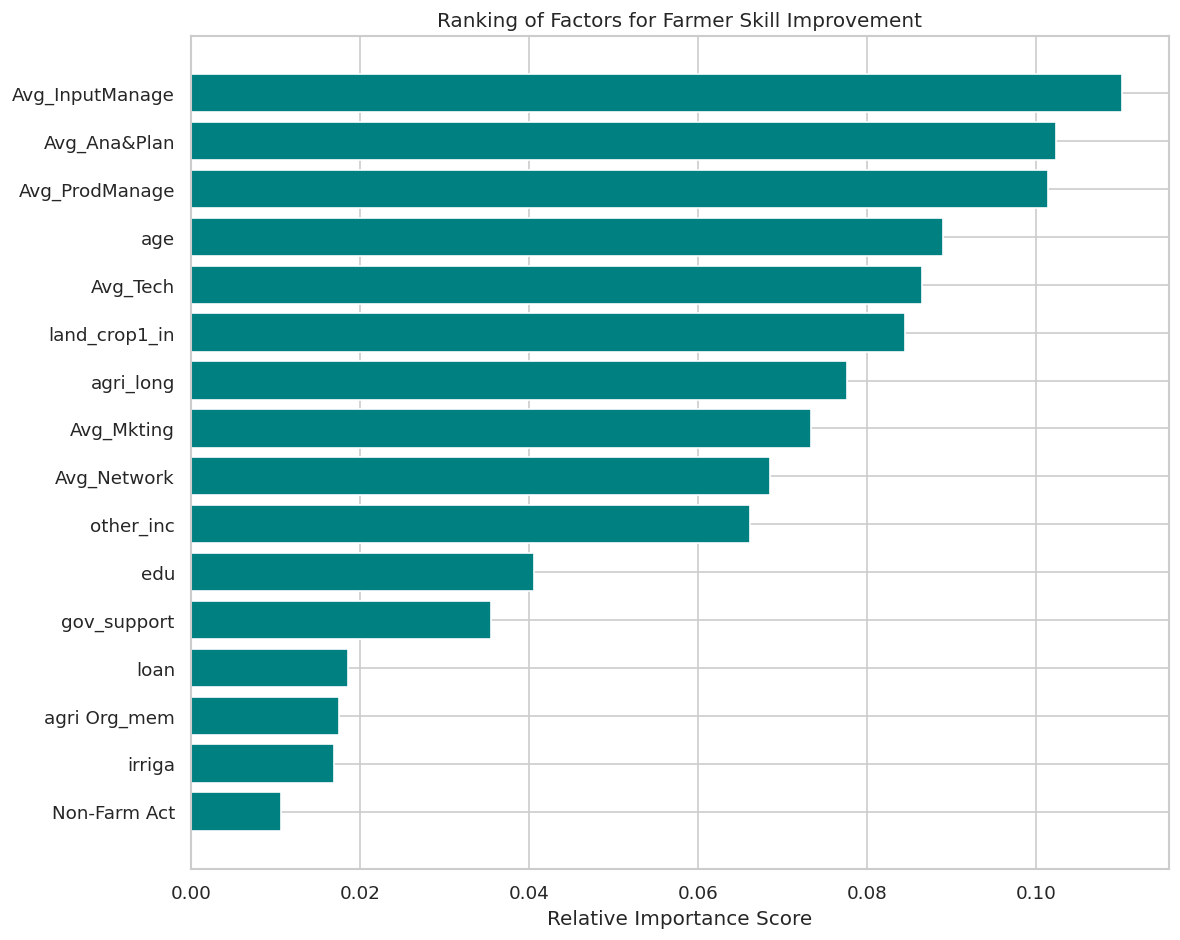

In [39]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
# import shap # <--- สำหรับรันในเครื่องส่วนตัวที่มี library นี้

# 1. สร้างโมเดลจำแนกประเภท (Classification)
X = df_cleaned[features]
y = df_cleaned['Success_Target']
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# 2. การสร้างกราฟ Feature Importance (เพื่อดูการจัดลำดับปัจจัย)
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.title('Ranking of Factors for Farmer Skill Improvement')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance Score')
plt.tight_layout()
plt.show()

# 3. โค้ดสำหรับ SHAP (แนะนำให้ใช้ในเล่มวิจัย)
# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X)
# shap.summary_plot(shap_values[1], X) # สรุปปัจจัยบวก/ลบต่อการพัฒนาทักษะ

In [40]:
# --- LOGIC เดิมสำหรับการทำ Farmer Segmentation & Classification ---
# เป้าหมาย: พยากรณ์โอกาสความสำเร็จรายบุคคลเพื่อเลือกหลักสูตรที่เหมาะสม

import xgboost as xgb # หรือใช้ RandomForest แทนได้

# นิยามกลุ่มตัวแปรตามตรรกะเศรษฐศาสตร์
human_capital = ['age', 'edu', 'agri_long']
production_assets = ['land_crop1_in', 'irriga', 'gov_support']
financial_risk = ['loan', 'Non-Farm Act', 'Overview_Risk']
social_capital = ['agri Org_mem']
baseline_skills = ['Avg_ProdManage', 'Avg_InputManage', 'Avg_Tech', 'Avg_Ana&Plan', 'Avg_Mkting', 'Avg_Network']

all_features = human_capital + production_assets + financial_risk + social_capital + baseline_skills

# การสร้างโมเดลเพื่อใช้พยากรณ์ล่วงหน้า (Predictive Model)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
final_model = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05)
final_model.fit(X_train, y_train)

# การวัดผล (Evaluation Metrics)
print(classification_report(y_test, final_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.65      0.59      0.62        86
           1       0.61      0.67      0.64        81

    accuracy                           0.63       167
   macro avg       0.63      0.63      0.63       167
weighted avg       0.63      0.63      0.63       167



# การวิเคราะห์ข้อมูลโครงการ Smart Farmer (Panel Data)

**วัตถุประสงค์:**
1. วิเคราะห์ความสัมพันธ์ระหว่างการเปลี่ยนแปลงของทักษะเกษตรกรกับคุณลักษณะของหลักสูตรการฝึกอบรม
2. นำเสนอกรอบการเรียนรู้เกษตรกรรมอัจฉริยะที่มีประสิทธิผลสำหรับเกษตรกรแต่ละกลุ่มโดยใช้ Machine Learning

---
**แนวทางการวิเคราะห์:**
- Obj 1: DiD → Correlation → OLS Regression → **SHAP (Beeswarm)**
- Obj 2: K-Means Clustering → PCA → RF Feature Importance → **SHAP (Dependence + Per-Cluster)** → Learning Framework

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Statistics
from scipy import stats
from scipy.stats import pearsonr, ttest_ind

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import silhouette_score

# SHAP — explainability
import shap
from pyprojroot import here

# Style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

# ─── Helper: OLS ด้วย numpy + scipy (ไม่ต้องติดตั้ง statsmodels) ───────────
def ols_with_pvalues(X, y):
    """OLS regression → beta, SE, t-stat, p-value, R², Adj-R²"""
    X_c = np.column_stack([np.ones(len(X)), X])
    n, k = X_c.shape
    beta, _, _, _ = np.linalg.lstsq(X_c, y, rcond=None)
    y_hat = X_c @ beta
    resid = y - y_hat
    s2    = (resid @ resid) / (n - k)
    se    = np.sqrt(s2 * np.diag(np.linalg.pinv(X_c.T @ X_c)))
    t_s   = beta / se
    p_v   = 2 * (1 - stats.t.cdf(np.abs(t_s), df=n - k))
    r2    = 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)
    r2a   = 1 - (1 - r2) * (n - 1) / (n - k)
    return beta, se, t_s, p_v, r2, r2a

print('Setup complete.')

Setup complete.


## 1. Load & Explore Data

In [42]:
# หาตำแหน่งของโฟลเดอร์ที่ไฟล์ code นี้วางอยู่
base_path = here()
file_path = os.path.join(base_path, "datas", "SFProgramDataPanal.csv")
# file_path = os.path.join(base_path, "data", "SFProgramDataPanal.csv")

df = pd.read_csv(file_path)

print(f'Shape: {df.shape}')
print(f'SF Participants (1): {(df.sf_participant==1).sum()}  |  Non-Participants (0): {(df.sf_participant==0).sum()}')
print(f'Year 0 (Before)    : {(df.Year==0).sum()}  |  Year 1 (After): {(df.Year==1).sum()}')

# ─── Variable groups ────────────────────────────────────────────────────────
SKILL_AVG    = ['Avg_ProdManage','Avg_InputManage','Avg_Tech','Avg_Ana&Plan','Avg_Mkting','Avg_Network']
SKILL_CH     = ['Ch_ProdManage','Ch_InputManage','Ch_Tech','Ch_Ana&Plan','Ch_Mkting','Ch_Network','Ch_Skill']
SKILL_LABELS = ['ProdManage','InputManage','Technology','Ana&Plan','Marketing','Network','Overall']
TRAIN_VARS   = ['29.agri_learning_chan','31.1Adapt_tech_prod','31.2farm_manag',
                '31.3agri_entrep','31.4val_added']
TRAIN_LABELS = ['Learning Channel','Tech Production','Farm Management',
                'Agri-Entrepreneurship','Value Added']
DEMO_COLS    = ['age','edu','agri_long','irriga','loan']

df_sf = df[df['sf_participant'] == 1].copy()
df_nf = df[df['sf_participant'] == 0].copy()

df.head(2)

Shape: (834, 68)
SF Participants (1): 429  |  Non-Participants (0): 405
Year 0 (Before)    : 417  |  Year 1 (After): 417


,id,sf_participant,region,gender,age,edu,status,hh_mem,agri_long,irriga,...,Avg_Mkting,Avg_Network,All_Skill,Ch_ProdManage,Ch_InputManage,Ch_Tech,Ch_Ana&Plan,Ch_Mkting,Ch_Network,Ch_Skill
0,22,0,5,1,30,5,1,5.0,12.0,0,...,2.33,3.0,3.03,0.2,0.000000,0.25,0.2,0.670000,0.00,0.220000
1,22,0,5,1,30,5,1,5.0,12.0,0,...,1.67,3.0,2.81,-1.8,-0.333333,-1.25,-1.4,-2.666667,-1.75,-1.533333


In [43]:
print('=== Descriptive Statistics: Skill Change by Group ===')
df.groupby('sf_participant')[SKILL_CH].agg(['mean','std']).round(3)

=== Descriptive Statistics: Skill Change by Group ===


Ch_ProdManage        Ch_InputManage        Ch_Tech         \
                        mean    std           mean    std    mean    std   
sf_participant                                                             
0                     -0.022  0.705         -0.020  0.801  -0.031  0.878   
1                      0.018  0.820          0.016  0.746   0.028  0.900   

               Ch_Ana&Plan        Ch_Mkting        Ch_Network        Ch_Skill  \
                      mean    std      mean    std       mean    std     mean   
sf_participant                                                                  
0                   -0.036  0.827    -0.029  0.965     -0.058  0.936   -0.033   
1                    0.032  0.804     0.023  0.958      0.058  0.987    0.029   

                       
                  std  
sf_participant         
0               0.700  
1               0.692

---
## 2. Objective 1 — ความสัมพันธ์ระหว่างการเปลี่ยนแปลงทักษะกับคุณลักษณะหลักสูตร

In [44]:
print('=== Descriptive Statistics: Skill Change by Group ===')
df.groupby('sf_participant')[SKILL_CH].agg(['mean','std']).round(3)

=== Descriptive Statistics: Skill Change by Group ===


Ch_ProdManage        Ch_InputManage        Ch_Tech         \
                        mean    std           mean    std    mean    std   
sf_participant                                                             
0                     -0.022  0.705         -0.020  0.801  -0.031  0.878   
1                      0.018  0.820          0.016  0.746   0.028  0.900   

               Ch_Ana&Plan        Ch_Mkting        Ch_Network        Ch_Skill  \
                      mean    std      mean    std       mean    std     mean   
sf_participant                                                                  
0                   -0.036  0.827    -0.029  0.965     -0.058  0.936   -0.033   
1                    0.032  0.804     0.023  0.958      0.058  0.987    0.029   

                       
                  std  
sf_participant         
0               0.700  
1               0.692

### 2.1 Difference-in-Differences (DiD)

In [45]:
did_table = df.groupby(['sf_participant','Year'])[SKILL_AVG + ['All_Skill']].mean()
cols_did  = SKILL_AVG + ['All_Skill']

rows = []
for col, lbl in zip(cols_did, SKILL_LABELS[:6] + ['All_Skill']):
    sf_b  = did_table.loc[(1,0), col]
    sf_a  = did_table.loc[(1,1), col]
    nsf_b = did_table.loc[(0,0), col]
    nsf_a = did_table.loc[(0,1), col]
    rows.append({'Skill':lbl, 'SF Before':sf_b, 'SF After':sf_a,
                 'NSF Before':nsf_b, 'NSF After':nsf_a, 'DiD':(sf_a-sf_b)-(nsf_a-nsf_b)})
df_did = pd.DataFrame(rows).set_index('Skill')
print(df_did.round(4))

# t-tests
print('\n=== t-tests: Skill Change (SF vs Non-SF) ===')
print(f'{"Skill":<14} {"SF Mean":>9} {"NSF Mean":>9} {"t":>7} {"p":>9} {"Sig":>5}')
print('-' * 54)
for col, lbl in zip(SKILL_CH, SKILL_LABELS):
    t, p = ttest_ind(df_sf[col].dropna(), df_nf[col].dropna())
    sig  = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    print(f'{lbl:<14} {df_sf[col].mean():>9.4f} {df_nf[col].mean():>9.4f} {t:>7.3f} {p:>9.4f} {sig:>5}')

             SF Before  SF After  NSF Before  NSF After     DiD
Skill                                                          
ProdManage      3.9730    4.2627      3.5332     3.7616  0.0612
InputManage     3.7991    4.0691      3.3631     3.6894 -0.0564
Technology      3.7453    4.0448      3.2228     3.5062  0.0160
Ana&Plan        3.7423    4.0180      3.0507     3.3470 -0.0206
Marketing       3.4824    3.7903      2.7278     3.0886 -0.0529
Network         3.7221    3.9934      2.9369     3.2315 -0.0234
All_Skill       3.7451    4.0293      3.1393     3.4376 -0.0140

=== t-tests: Skill Change (SF vs Non-SF) ===
Skill            SF Mean  NSF Mean       t         p   Sig
------------------------------------------------------
ProdManage        0.0176   -0.0222   0.748    0.4546    ns
InputManage       0.0155   -0.0198   0.659    0.5098    ns
Technology        0.0280   -0.0309   0.955    0.3397    ns
Ana&Plan          0.0317   -0.0356   1.191    0.2339    ns
Marketing         0.0233   -

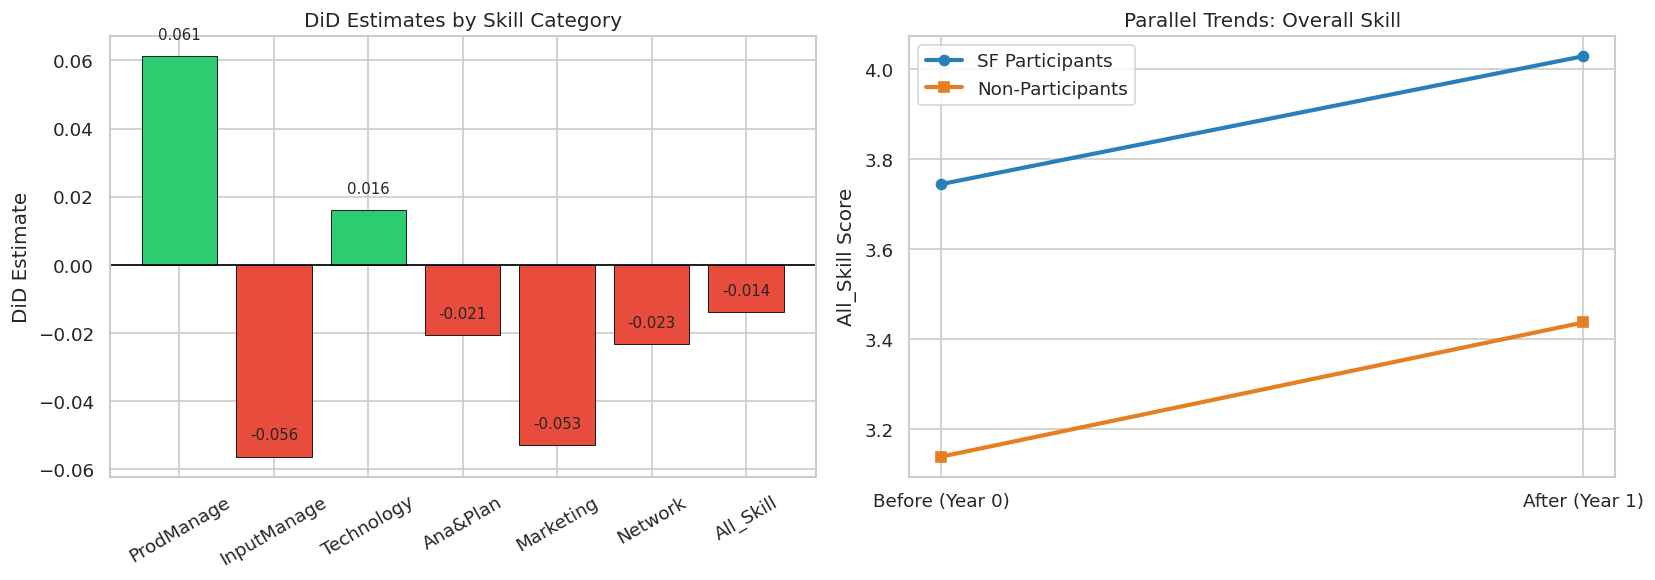

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DiD bar
clrs = ['#2ecc71' if v >= 0 else '#e74c3c' for v in df_did['DiD']]
axes[0].bar(df_did.index, df_did['DiD'], color=clrs, edgecolor='black', linewidth=0.5)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set(title='DiD Estimates by Skill Category', ylabel='DiD Estimate')
axes[0].tick_params(axis='x', rotation=30)
for i, (_, row) in enumerate(df_did.iterrows()):
    axes[0].text(i, row['DiD'] + 0.005, f"{row['DiD']:.3f}", ha='center', fontsize=9)

# Parallel trends
for grp, lbl, clr, mk in [(1,'SF Participants','#2980b9','o'),(0,'Non-Participants','#e67e22','s')]:
    vals = df[df['sf_participant']==grp].groupby('Year')['All_Skill'].mean()
    axes[1].plot([0,1], [vals[0],vals[1]], marker=mk, linewidth=2.5, color=clr, label=lbl)
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['Before (Year 0)','After (Year 1)'])
axes[1].set(title='Parallel Trends: Overall Skill', ylabel='All_Skill Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_DiD.png', bbox_inches='tight')
plt.show()

### 2.2 Correlation: Skill Change vs Training Characteristics

In [47]:
print('=== Pearson Correlation: Skill Change vs Training (SF Participants) ===')
print(f'{"":>14}', end='')
for tl in TRAIN_LABELS:
    print(f'  {tl[:11]:>13}', end='')
print()

corr_dict = {}
for sc, sl in zip(SKILL_CH, SKILL_LABELS):
    row_r = []
    print(f'{sl:>14}', end='')
    for tv in TRAIN_VARS:
        tmp = df_sf[[sc, tv]].dropna()
        r, p = pearsonr(tmp[sc], tmp[tv]) if len(tmp) > 5 else (np.nan, np.nan)
        sig  = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else ''))
        print(f'  {r:>6.3f}{sig:>4}  ', end='')
        row_r.append(r)
    corr_dict[sl] = row_r
    print()

corr_df = pd.DataFrame(corr_dict, index=TRAIN_LABELS).T

=== Pearson Correlation: Skill Change vs Training (SF Participants) ===
                  Learning Ch    Tech Produc    Farm Manage    Agri-Entrep    Value Added
    ProdManage  -0.066         0.069         0.013         0.087        -0.034      
   InputManage  -0.045         0.097        -0.007         0.099        -0.001      
    Technology  -0.081         0.113         0.006         0.117         0.051      
      Ana&Plan  -0.087         0.116         0.030         0.172  **     0.063      
     Marketing  -0.092         0.227 ***     0.054         0.200  **     0.078      
       Network  -0.068         0.121         0.049         0.159   *     0.002      
       Overall  -0.093         0.156   *     0.032         0.175  **     0.035      


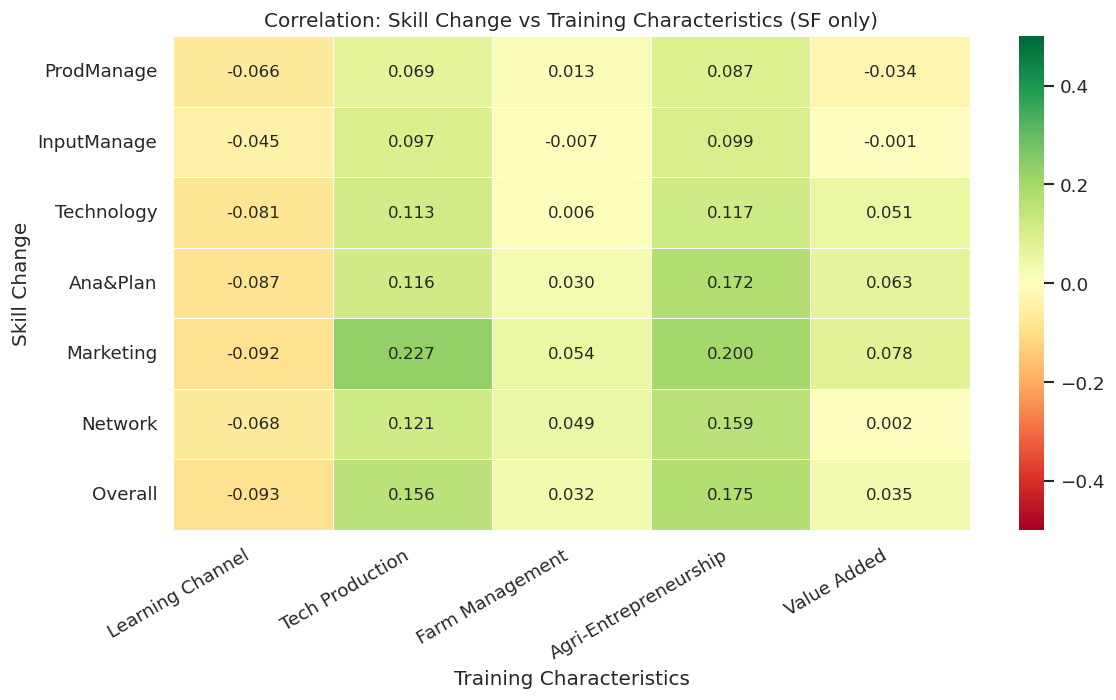

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-0.5, vmax=0.5, linewidths=0.5,
            ax=ax, annot_kws={'size':10})
ax.set(title='Correlation: Skill Change vs Training Characteristics (SF only)',
       xlabel='Training Characteristics', ylabel='Skill Change')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_Correlation.png', bbox_inches='tight')
plt.show()

### 2.3 OLS Regression: Training Characteristics → Overall Skill Change

In [49]:
df_reg = df_sf[['Ch_Skill'] + TRAIN_VARS + DEMO_COLS].dropna().copy()
y_reg  = df_reg['Ch_Skill'].values

# Model 1: Training only
X1 = df_reg[TRAIN_VARS].values
b1, se1, t1, p1, r2_1, r2a_1 = ols_with_pvalues(X1, y_reg)

# Model 2: Training + Demographics
X2 = df_reg[TRAIN_VARS + DEMO_COLS].values
b2, se2, t2, p2, r2_2, r2a_2 = ols_with_pvalues(X2, y_reg)

def print_reg(beta, se, t_, p_, r2, r2a, var_names, n):
    print(f'{"Variable":<25} {"Coef":>8} {"SE":>8} {"t":>8} {"p":>10} {"Sig":>5}')
    print('-' * 66)
    for nm, b, s, tv, pv in zip(['const']+var_names, beta, se, t_, p_):
        sig = '***' if pv<0.001 else ('**' if pv<0.01 else ('*' if pv<0.05 else 'ns'))
        print(f'{nm:<25} {b:>8.4f} {s:>8.4f} {tv:>8.3f} {pv:>10.4f} {sig:>5}')
    print(f'R²={r2:.4f}  Adj-R²={r2a:.4f}  N={n}')

print('=== Model 1: Training Variables → Ch_Skill ===')
print_reg(b1, se1, t1, p1, r2_1, r2a_1, TRAIN_LABELS, len(y_reg))

print('\n=== Model 2: Training + Demographics → Ch_Skill ===')
print_reg(b2, se2, t2, p2, r2_2, r2a_2, TRAIN_LABELS + DEMO_COLS, len(y_reg))

=== Model 1: Training Variables → Ch_Skill ===
Variable                      Coef       SE        t          p   Sig
------------------------------------------------------------------
const                      -0.0056   0.2693   -0.021     0.9836    ns
Learning Channel           -0.0568   0.0500   -1.134     0.2579    ns
Tech Production             0.2600   0.1979    1.314     0.1903    ns
Farm Management            -0.3681   0.2535   -1.452     0.1479    ns
Agri-Entrepreneurship       0.5136   0.2067    2.485     0.0137     *
Value Added                -0.1831   0.1571   -1.165     0.2452    ns
R²=0.0534  Adj-R²=0.0325  N=232

=== Model 2: Training + Demographics → Ch_Skill ===
Variable                      Coef       SE        t          p   Sig
------------------------------------------------------------------
const                       0.1296   0.4510    0.287     0.7741    ns
Learning Channel           -0.0559   0.0510   -1.097     0.2739    ns
Tech Production             0.2794

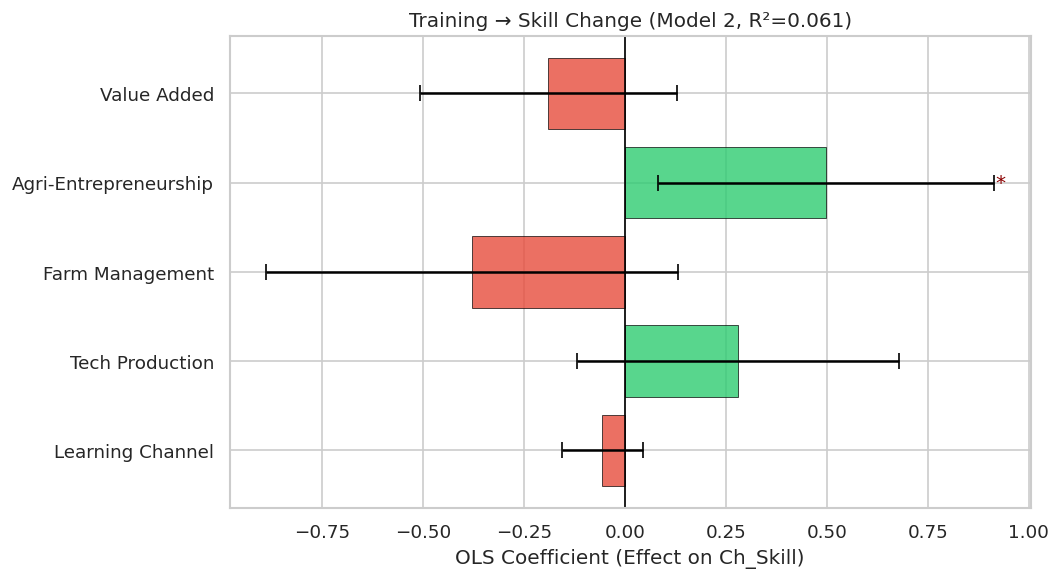

In [50]:
# Coefficient plot — training vars from Model 2
coefs_t = b2[1:len(TRAIN_VARS)+1]
ses_t   = se2[1:len(TRAIN_VARS)+1]
ps_t    = p2[1:len(TRAIN_VARS)+1]

fig, ax = plt.subplots(figsize=(9, 5))
clrs_r  = ['#2ecc71' if c >= 0 else '#e74c3c' for c in coefs_t]
for i, (nm, c, se_, p_) in enumerate(zip(TRAIN_LABELS, coefs_t, ses_t, ps_t)):
    ax.barh(i, c, color=clrs_r[i], alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.errorbar(c, i, xerr=1.96*se_, fmt='none', color='black', capsize=5)
    sig = '***' if p_<0.001 else ('**' if p_<0.01 else ('*' if p_<0.05 else ''))
    ax.text(c + 1.96*se_ + 0.003, i, sig, va='center', fontsize=12, color='darkred')
ax.set_yticks(range(len(TRAIN_LABELS)))
ax.set_yticklabels(TRAIN_LABELS)
ax.axvline(0, color='black', linewidth=1)
ax.set(xlabel='OLS Coefficient (Effect on Ch_Skill)',
       title=f'Training → Skill Change (Model 2, R²={r2_2:.3f})')
plt.tight_layout()
plt.savefig('fig_Regression.png', bbox_inches='tight')
plt.show()

In [51]:
# Per-skill regression summary
ch_sub  = ['Ch_ProdManage','Ch_InputManage','Ch_Tech','Ch_Ana&Plan','Ch_Mkting','Ch_Network']
ctrl    = ['age','edu','agri_long']
print('=== Per-Skill Regression (Coef + Sig) ===')
print(f'{"Skill":<14} {"R2":>5}  ', end='')
for tl in TRAIN_LABELS:
    print(f'{tl[:10]:>14}', end='')
print()
print('-' * (14 + 7 + 14*len(TRAIN_LABELS)))
for sc, sl in zip(ch_sub, SKILL_LABELS[:6]):
    tmp = df_sf[[sc]+TRAIN_VARS+ctrl].dropna()
    Xp  = tmp[TRAIN_VARS+ctrl].values
    yp  = tmp[sc].values
    bp, sep, tp, pp, r2p, _ = ols_with_pvalues(Xp, yp)
    print(f'{sl:<14} {r2p:>5.3f}  ', end='')
    for j in range(len(TRAIN_VARS)):
        sig = '***' if pp[j+1]<0.001 else ('**' if pp[j+1]<0.01 else ('*' if pp[j+1]<0.05 else ''))
        print(f'  {bp[j+1]:>7.3f}{sig:<3}   ', end='')
    print()

=== Per-Skill Regression (Coef + Sig) ===
Skill             R2      Learning C    Tech Produ    Farm Manag    Agri-Entre    Value Adde
-------------------------------------------------------------------------------------------
ProdManage     0.025     -0.005          0.181         -0.254          0.378         -0.267      
InputManage    0.028      0.011          0.256         -0.366          0.388         -0.216      
Technology     0.036     -0.049          0.227         -0.344          0.366         -0.047      
Ana&Plan       0.049     -0.093          0.109         -0.397          0.607*        -0.088      
Marketing      0.079     -0.101          0.609*        -0.448          0.621*        -0.149      
Network        0.049     -0.107          0.211         -0.390          0.704*        -0.299      


### 2.4 SHAP Analysis — ปัจจัยใดส่งผลต่อ Ch_Skill มากที่สุด และในทิศทางใด

ใช้ `shap.TreeExplainer` บน `RandomForestRegressor` (target = Ch_Skill แบบต่อเนื่อง)
เพื่ออธิบายขนาดและทิศทางของผลกระทบแต่ละตัวแปรในระดับ instance

In [52]:
# ─── สร้าง RF Regressor สำหรับ SHAP ────────────────────────────────────────
# ใช้เฉพาะ SF Participants เพราะเราต้องการอธิบายผลของโครงการ

shap_features = TRAIN_VARS + ['age','edu','agri_long','irriga','loan',
                               'Avg_ProdManage','Avg_Tech','Avg_Mkting',
                               'Ave_MktRisk','Ave_FinRisk','Overview_Risk',
                               'agri Org_mem','gov_support']

# rename ชื่อ column ให้อ่านง่ายสำหรับกราฟ
rename_map = {
    '29.agri_learning_chan' : 'Learning Channel',
    '31.1Adapt_tech_prod'   : 'Train: Tech Prod',
    '31.2farm_manag'        : 'Train: Farm Mgmt',
    '31.3agri_entrep'       : 'Train: Entrep',
    '31.4val_added'         : 'Train: Value Added',
    'Avg_ProdManage'        : 'Avg ProdManage',
    'Avg_Tech'              : 'Avg Tech',
    'Avg_Mkting'            : 'Avg Mkting',
    'Ave_MktRisk'           : 'Market Risk',
    'Ave_FinRisk'           : 'Financial Risk',
    'Overview_Risk'         : 'Overview Risk',
    'agri Org_mem'          : 'Agri Org Membership',
    'gov_support'           : 'Gov Support',
    'agri_long'             : 'Agri Experience',
}

df_shap1 = df_sf[shap_features + ['Ch_Skill']].dropna().copy()
df_shap1 = df_shap1.rename(columns=rename_map)
feat_cols_shap = [rename_map.get(f, f) for f in shap_features]

X_shap = df_shap1[feat_cols_shap]
y_shap = df_shap1['Ch_Skill']

rf_shap = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_shap.fit(X_shap, y_shap)

cv_r2 = cross_val_score(rf_shap, X_shap, y_shap, cv=5, scoring='r2')
print(f'RF for SHAP — CV R²: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'Training samples: {len(X_shap)}')

RF for SHAP — CV R²: 0.0976 ± 0.2066
Training samples: 228


In [53]:
# ─── คำนวณ SHAP values ────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(rf_shap)
shap_values = explainer.shap_values(X_shap)

print(f'SHAP values shape: {shap_values.shape}')
# print(f'Expected value (base rate): {explainer.expected_value:.4f}')
print(f'Expected value (base rate): {explainer.expected_value.item():.4f}')

SHAP values shape: (228, 18)
Expected value (base rate): 0.0974


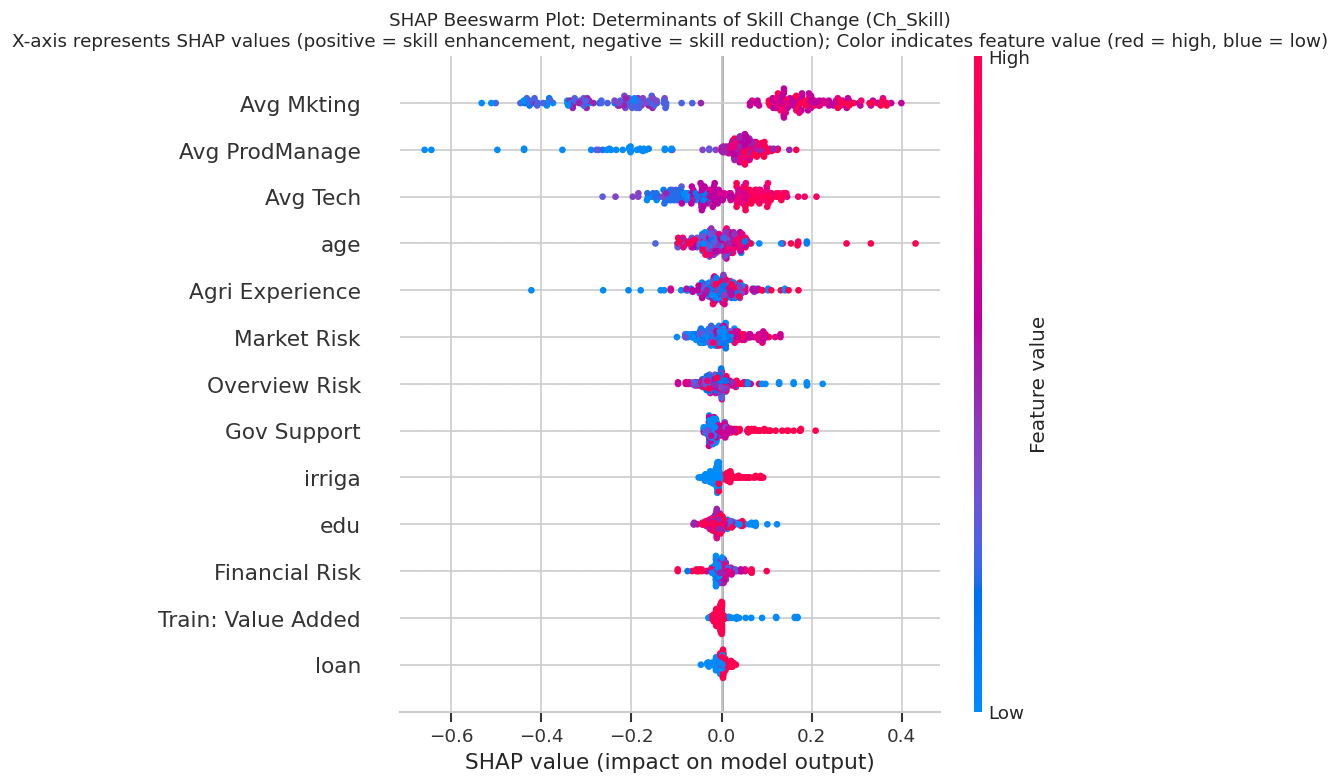

Figure saved: fig_SHAP_Beeswarm.png


In [54]:
# ─── SHAP Beeswarm Plot ────────────────────────────────────────────────────
# อ่านว่า: แกน x = ขนาดและทิศทางที่ตัวแปรนั้นดัน/ดึง Ch_Skill ของแต่ละ farmer
#          สี = ค่าตัวแปรนั้น (แดง = สูง, น้ำเงิน = ต่ำ)

shap.initjs()

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_shap,
    plot_type='dot',        # beeswarm
    max_display=13,
    show=False
)
plt.title(
    "SHAP Beeswarm Plot: Determinants of Skill Change (Ch_Skill)\n"
    "X-axis represents SHAP values (positive = skill enhancement, negative = skill reduction); "
    "Color indicates feature value (red = high, blue = low)",
    fontsize=11
)
plt.tight_layout()
plt.savefig('fig_SHAP_Beeswarm.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_SHAP_Beeswarm.png')

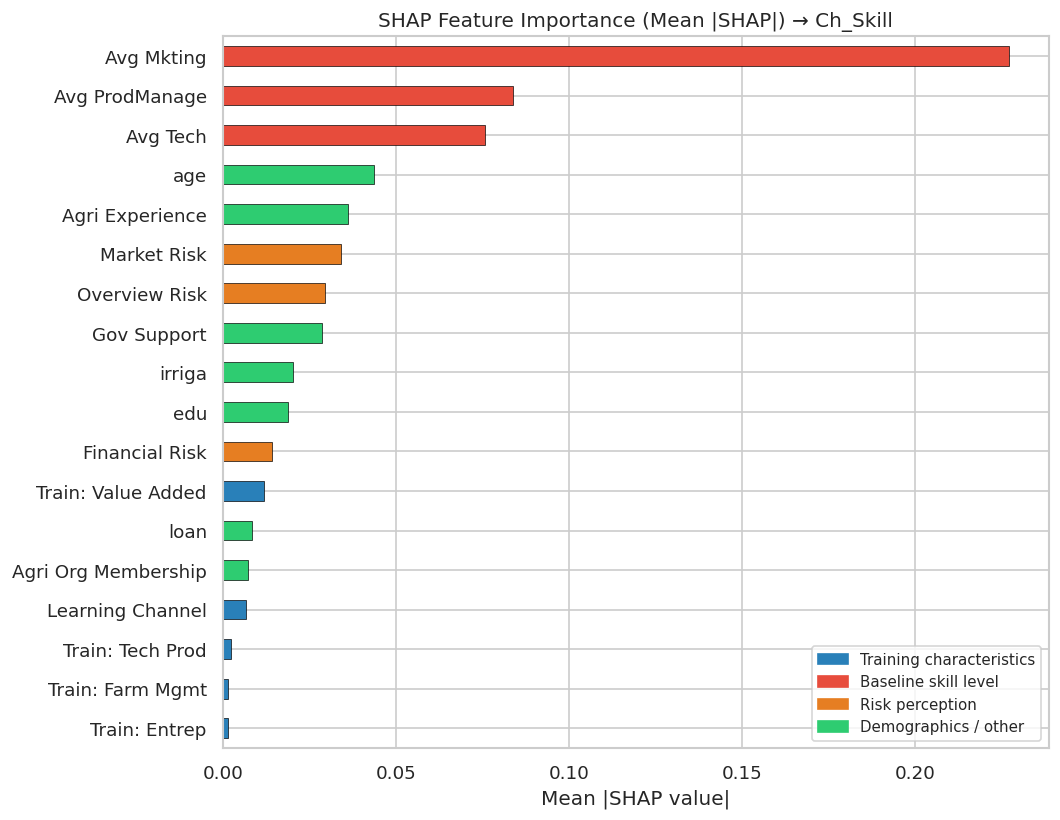

Figure saved: fig_SHAP_Bar.png


In [55]:
# ─── SHAP Mean |SHAP| Bar — Global Feature Importance ─────────────────────
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feat_cols_shap
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
# แยกสีตามกลุ่มตัวแปร
clr_map = {}
for f in mean_shap.index:
    if 'Train' in f or 'Channel' in f:
        clr_map[f] = '#2980b9'   # ตัวแปรหลักสูตร → น้ำเงิน
    elif 'Avg' in f:
        clr_map[f] = '#e74c3c'   # ทักษะพื้นฐาน → แดง
    elif 'Risk' in f:
        clr_map[f] = '#e67e22'   # ความเสี่ยง → ส้ม
    else:
        clr_map[f] = '#2ecc71'   # demographics/อื่นๆ → เขียว

mean_shap.plot(kind='barh', ax=ax,
               color=[clr_map[f] for f in mean_shap.index],
               edgecolor='black', linewidth=0.4)
ax.set(title='SHAP Feature Importance (Mean |SHAP|) → Ch_Skill',
       xlabel='Mean |SHAP value|')

legend_items = [
    mpatches.Patch(color='#2980b9', label='Training characteristics'),
    mpatches.Patch(color='#e74c3c', label='Baseline skill level'),
    mpatches.Patch(color='#e67e22', label='Risk perception'),
    mpatches.Patch(color='#2ecc71', label='Demographics / other'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('fig_SHAP_Bar.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_SHAP_Bar.png')

---
## 3. Objective 2 — Smart Farming Learning Framework ด้วย Machine Learning

### 3.1 Optimal Clusters (Elbow + Silhouette)

Clustering dataset: (833, 15)


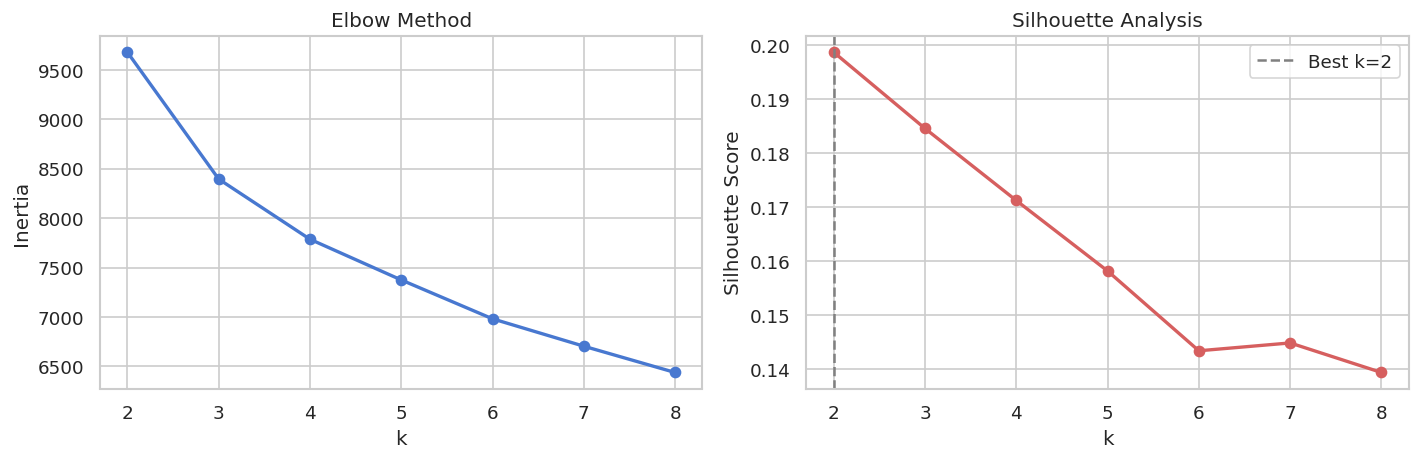

Best k = 2  |  Silhouette = 0.1986


In [56]:
cluster_features = ['age','edu','agri_long','irriga','loan',
                     'Avg_ProdManage','Avg_InputManage','Avg_Tech',
                     'Avg_Ana&Plan','Avg_Mkting','Avg_Network',
                     'Ave_ProdRisk','Ave_InputRisk','Ave_MktRisk','Ave_FinRisk']

df_cl  = df[cluster_features].dropna().copy()
idx_cl = df_cl.index
scaler = StandardScaler()
X_sc   = scaler.fit_transform(df_cl)
print(f'Clustering dataset: {df_cl.shape}')

inertias, sil_scores = [], []
for k in range(2, 9):
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_sc)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sc, lbl))

best_k = list(range(2,9))[sil_scores.index(max(sil_scores))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(2,9), inertias, 'b-o', linewidth=2)
axes[0].set(xlabel='k', ylabel='Inertia', title='Elbow Method')
axes[1].plot(range(2,9), sil_scores, 'r-o', linewidth=2)
axes[1].axvline(best_k, color='gray', linestyle='--', label=f'Best k={best_k}')
axes[1].set(xlabel='k', ylabel='Silhouette Score', title='Silhouette Analysis')
axes[1].legend()
plt.tight_layout()
plt.savefig('fig_Elbow.png', bbox_inches='tight')
plt.show()
print(f'Best k = {best_k}  |  Silhouette = {max(sil_scores):.4f}')

### 3.2 K-Means Clustering & Cluster Profiles

In [57]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_cl['Cluster'] = km_final.fit_predict(X_sc)

df_main = df.loc[idx_cl].copy()
df_main['Cluster'] = df_cl['Cluster'].values

print('Cluster Distribution:')
print(df_cl['Cluster'].value_counts().sort_index())

cluster_profile = df_main.groupby('Cluster')[
    cluster_features + ['Ch_Skill','All_Skill','sf_participant']
].mean().round(3)
print('\nCluster Mean Profile:')
cluster_profile

Cluster Distribution:
Cluster
0    422
1    411
Name: count, dtype: int64

Cluster Mean Profile:


,age,edu,agri_long,irriga,loan,Avg_ProdManage,Avg_InputManage,Avg_Tech,Avg_Ana&Plan,Avg_Mkting,Avg_Network,Ave_ProdRisk,Ave_InputRisk,Ave_MktRisk,Ave_FinRisk,Ch_Skill,All_Skill,sf_participant
Cluster,,,,,,,,,,,,,,,,,,
0,52.908,3.735,18.310,0.320,0.443,4.389,4.225,4.259,4.160,3.920,4.149,1.925,1.928,1.716,2.314,0.248,4.184,0.716
1,52.754,3.187,23.294,0.217,0.562,3.375,3.234,2.999,2.923,2.628,2.798,2.535,2.543,2.317,2.942,-0.256,2.993,0.307


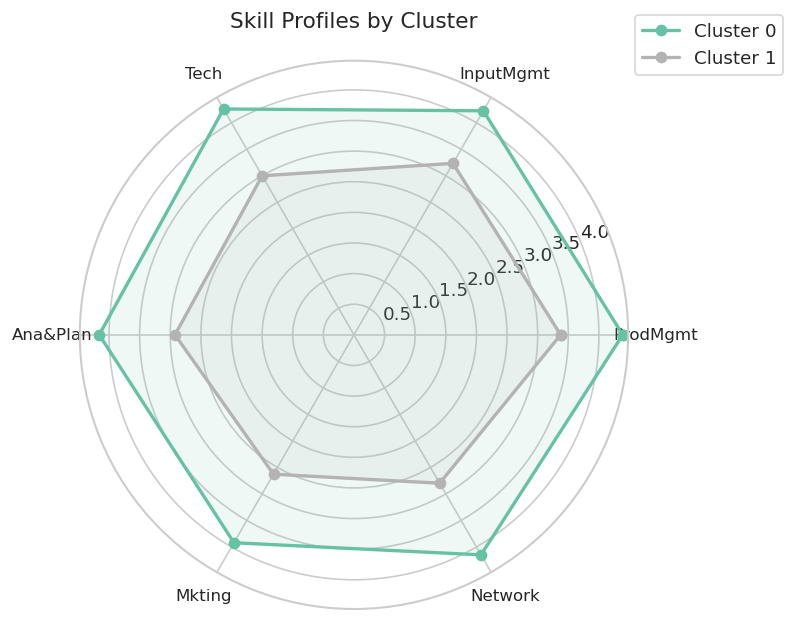

In [58]:
# Radar chart
skill_r = ['Avg_ProdManage','Avg_InputManage','Avg_Tech','Avg_Ana&Plan','Avg_Mkting','Avg_Network']
rlbls   = ['ProdMgmt','InputMgmt','Tech','Ana&Plan','Mkting','Network']
N       = len(skill_r)
angles  = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
palette = plt.cm.Set2(np.linspace(0, 1, best_k))

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for i in range(best_k):
    vals = cluster_profile.loc[i, skill_r].tolist() + [cluster_profile.loc[i, skill_r[0]]]
    ax.plot(angles, vals, 'o-', linewidth=2, color=palette[i], label=f'Cluster {i}')
    ax.fill(angles, vals, alpha=0.1, color=palette[i])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(rlbls, fontsize=10)
ax.set_title('Skill Profiles by Cluster', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('fig_RadarCluster.png', bbox_inches='tight')
plt.show()

### 3.3 PCA Visualization

Explained Variance: PC1=33.08%, PC2=17.09%


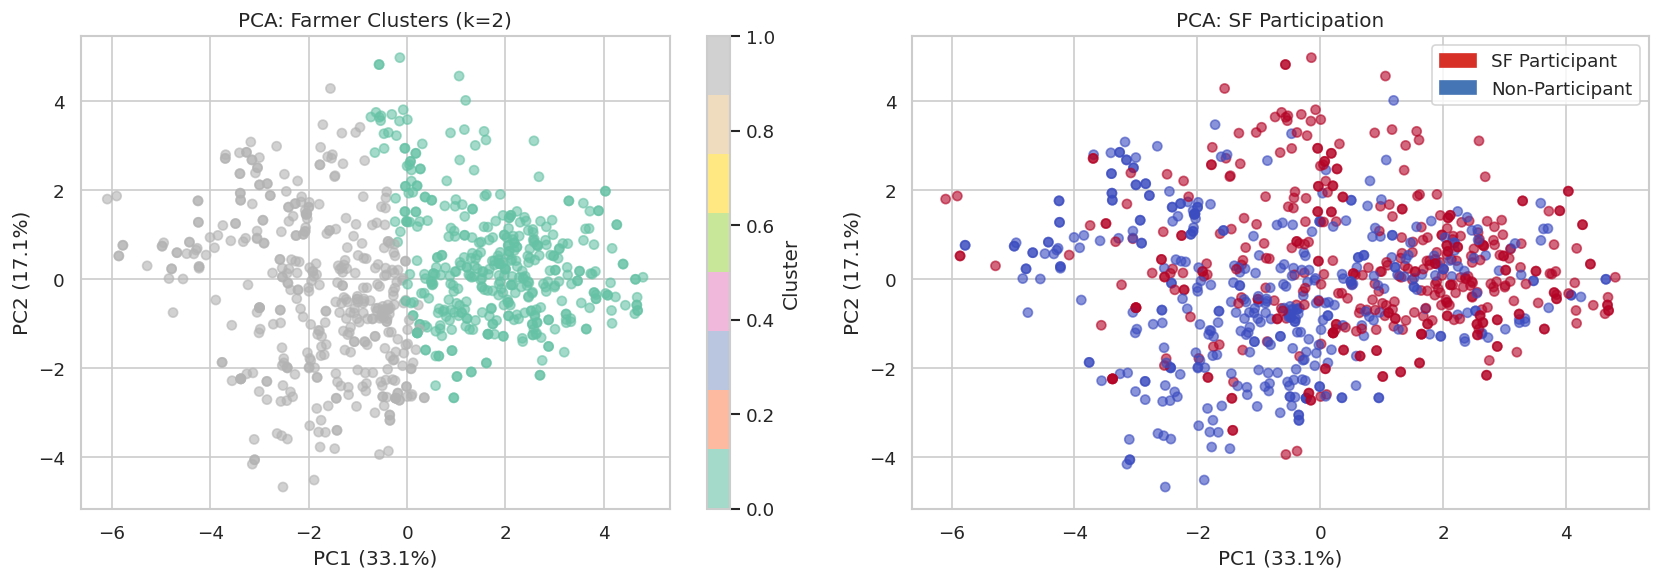

In [59]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sc)
print(f'Explained Variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=df_cl['Cluster'], cmap='Set2', alpha=0.6, s=30)
plt.colorbar(sc1, ax=axes[0], label='Cluster')
axes[0].set(title=f'PCA: Farmer Clusters (k={best_k})',
             xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
             ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

axes[1].scatter(X_pca[:,0], X_pca[:,1], c=df_main['sf_participant'], cmap='coolwarm', alpha=0.6, s=30)
leg_el = [mpatches.Patch(color='#d73027', label='SF Participant'),
          mpatches.Patch(color='#4575b4', label='Non-Participant')]
axes[1].legend(handles=leg_el)
axes[1].set(title='PCA: SF Participation',
             xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
             ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

plt.tight_layout()
plt.savefig('fig_PCA.png', bbox_inches='tight')
plt.show()

### 3.4 Random Forest + SHAP Dependence Plots

RF (all) — CV R²: 0.1793 ± 0.1179


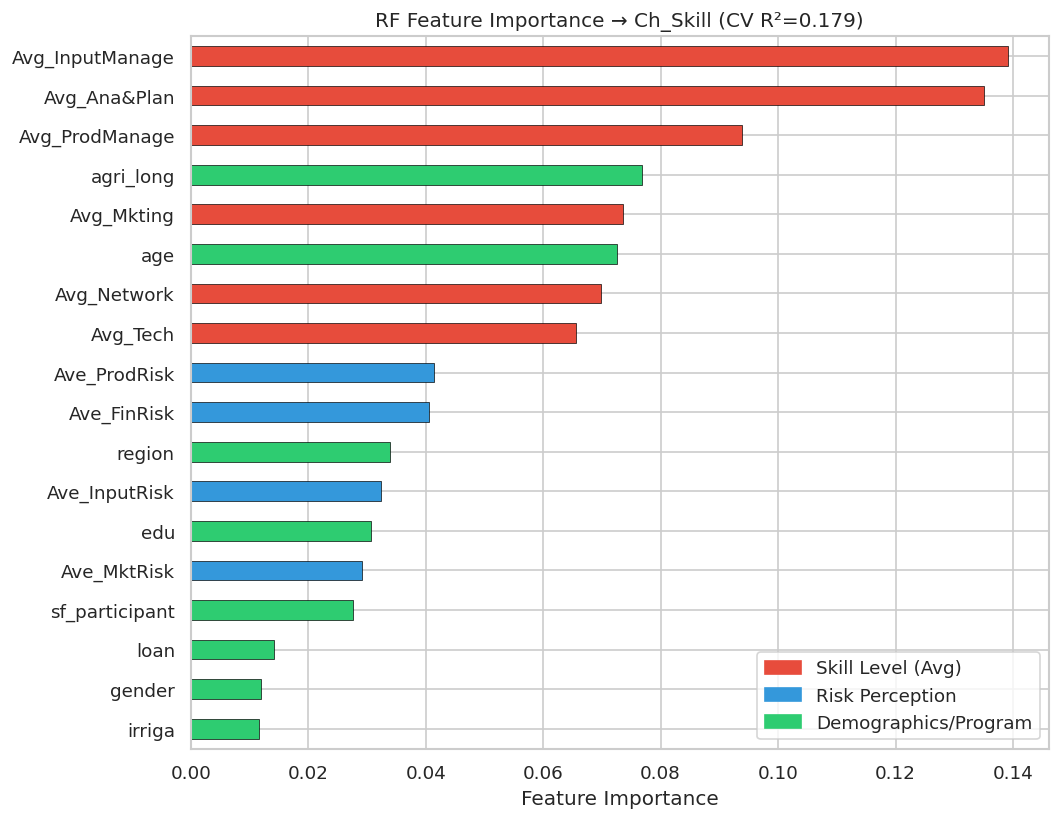

In [60]:
# ─── RF Regressor: ทั้ง dataset (SF + Non-SF) ──────────────────────────────
feat_cols_rf = ['age','edu','agri_long','gender','irriga','loan','region',
                'Avg_ProdManage','Avg_InputManage','Avg_Tech','Avg_Ana&Plan','Avg_Mkting','Avg_Network',
                'Ave_ProdRisk','Ave_InputRisk','Ave_MktRisk','Ave_FinRisk','sf_participant']

df_rf  = df[feat_cols_rf + ['Ch_Skill']].dropna()
X_rf   = df_rf[feat_cols_rf]
y_rf   = df_rf['Ch_Skill'].values

rf_main = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_main.fit(X_rf, y_rf)
cv_r2   = cross_val_score(rf_main, X_rf, y_rf, cv=5, scoring='r2')
print(f'RF (all) — CV R²: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')

# Feature importance bar
importances = pd.Series(rf_main.feature_importances_, index=feat_cols_rf).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
clrs = ['#e74c3c' if 'Avg_' in c else '#3498db' if 'Ave_' in c else '#2ecc71'
        for c in importances.index]
importances.plot(kind='barh', ax=ax, color=clrs, edgecolor='black', linewidth=0.4)
ax.set(title=f'RF Feature Importance → Ch_Skill (CV R²={cv_r2.mean():.3f})',
       xlabel='Feature Importance')
leg_el = [mpatches.Patch(color='#e74c3c', label='Skill Level (Avg)'),
          mpatches.Patch(color='#3498db', label='Risk Perception'),
          mpatches.Patch(color='#2ecc71', label='Demographics/Program')]
ax.legend(handles=leg_el, loc='lower right')
plt.tight_layout()
plt.savefig('fig_FeatureImportance.png', bbox_inches='tight')
plt.show()

Top 3 features by mean |SHAP|: ['Avg_InputManage', 'Avg_Ana&Plan', 'sf_participant']


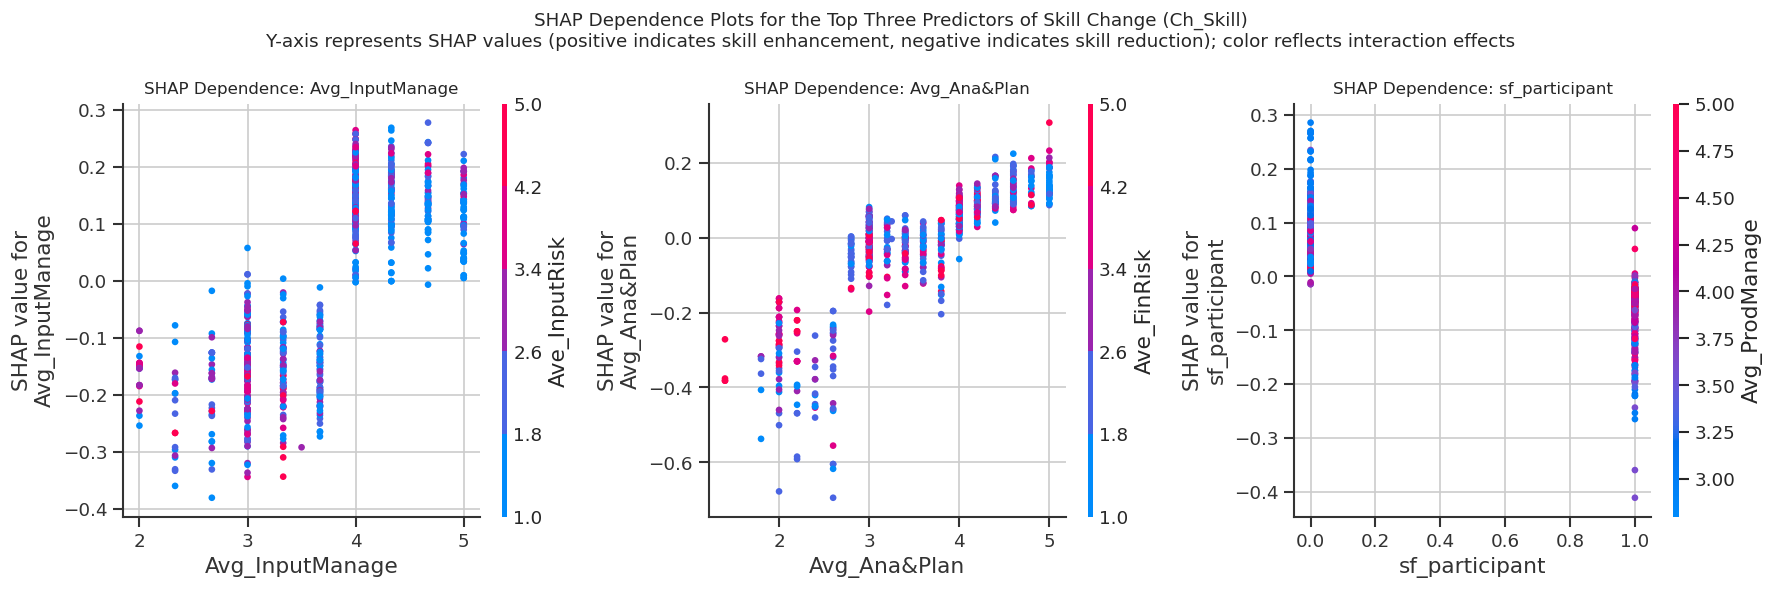

Figure saved: fig_SHAP_Dependence.png


In [61]:
# ─── SHAP Dependence Plots: Top 3 features ────────────────────────────────
# Dependence plot แสดงว่าค่าของตัวแปรนั้นสัมพันธ์กับ Ch_Skill อย่างไร
# และสีแสดง interaction effect กับตัวแปรที่ SHAP เลือกอัตโนมัติ

explainer_all  = shap.TreeExplainer(rf_main)
shap_values_all = explainer_all.shap_values(X_rf)

# หา top 3 features จาก mean |SHAP|
mean_shap_all = pd.Series(np.abs(shap_values_all).mean(axis=0), index=feat_cols_rf)
top3          = mean_shap_all.sort_values(ascending=False).head(3).index.tolist()
print(f'Top 3 features by mean |SHAP|: {top3}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax_, feat in zip(axes, top3):
    feat_idx = feat_cols_rf.index(feat)
    shap.dependence_plot(
        feat_idx, shap_values_all, X_rf,
        ax=ax_, show=False
    )
    ax_.set_title(f'SHAP Dependence: {feat}', fontsize=10)

plt.suptitle(
    "SHAP Dependence Plots for the Top Three Predictors of Skill Change (Ch_Skill)\n"
    "Y-axis represents SHAP values (positive indicates skill enhancement, negative indicates skill reduction); "
    "color reflects interaction effects",
    fontsize=11
)
plt.tight_layout()
plt.savefig('fig_SHAP_Dependence.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_SHAP_Dependence.png')

### 3.5 Smart Farmer Learning Framework per Cluster
#### 3.5.1 SHAP per Cluster — ปัจจัยสำคัญรายกลุ่ม

In [62]:
# ─── คำนวณ SHAP values เฉพาะแถวที่มี Cluster label ────────────────────────
df_rf_cl = df_rf.copy()
df_rf_cl = df_rf_cl.loc[df_rf_cl.index.isin(df_main.index)].copy()
df_rf_cl['Cluster'] = df_main.loc[df_rf_cl.index, 'Cluster'].values

X_rf_cl  = df_rf_cl[feat_cols_rf]
sv_cl    = explainer_all.shap_values(X_rf_cl)   # ใช้ explainer เดิม
df_sv_cl = pd.DataFrame(np.abs(sv_cl), columns=feat_cols_rf)
df_sv_cl['Cluster'] = df_rf_cl['Cluster'].values

# Mean |SHAP| per cluster
shap_per_cluster = df_sv_cl.groupby('Cluster')[feat_cols_rf].mean()

print('=== Mean |SHAP| per Cluster (Top 8 features) ===')
shap_per_cluster.T.sort_values(by=0, ascending=False).head(8).round(4)

=== Mean |SHAP| per Cluster (Top 8 features) ===


Cluster,0,1
Avg_InputManage,0.1441,0.1548
Avg_Ana&Plan,0.0893,0.1222
Avg_Mkting,0.0682,0.0564
Avg_Tech,0.0662,0.0338
sf_participant,0.0519,0.0863
Avg_ProdManage,0.0484,0.0790
Avg_Network,0.0399,0.0512
Ave_FinRisk,0.0380,0.0240


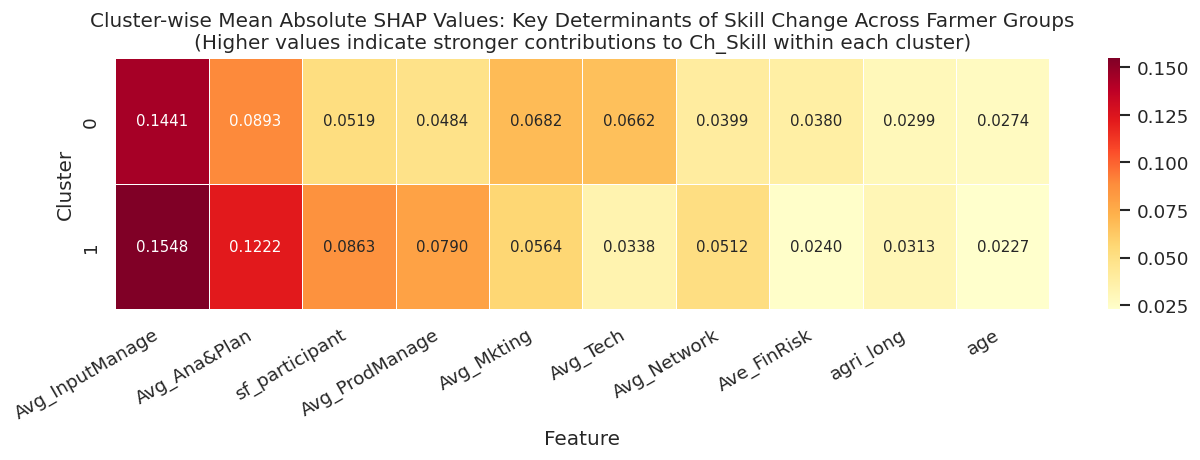

Figure saved: fig_SHAP_Cluster.png


In [63]:
# ─── Heatmap: SHAP importance per cluster (top 10 features globally) ───────
global_top10 = mean_shap_all.sort_values(ascending=False).head(10).index.tolist()
shap_heat    = shap_per_cluster[global_top10].copy()

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    shap_heat,
    annot=True, fmt='.4f', cmap='YlOrRd',
    linewidths=0.5, annot_kws={'size':9},
    ax=ax
)
ax.set(
    title="Cluster-wise Mean Absolute SHAP Values: Key Determinants of Skill Change Across Farmer Groups\n"
          "(Higher values indicate stronger contributions to Ch_Skill within each cluster)",
    xlabel="Feature",
    ylabel="Cluster"
)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_SHAP_Cluster.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_SHAP_Cluster.png')

#### 3.5.2 Learning Framework — รวม Cluster Profile + SHAP Insight

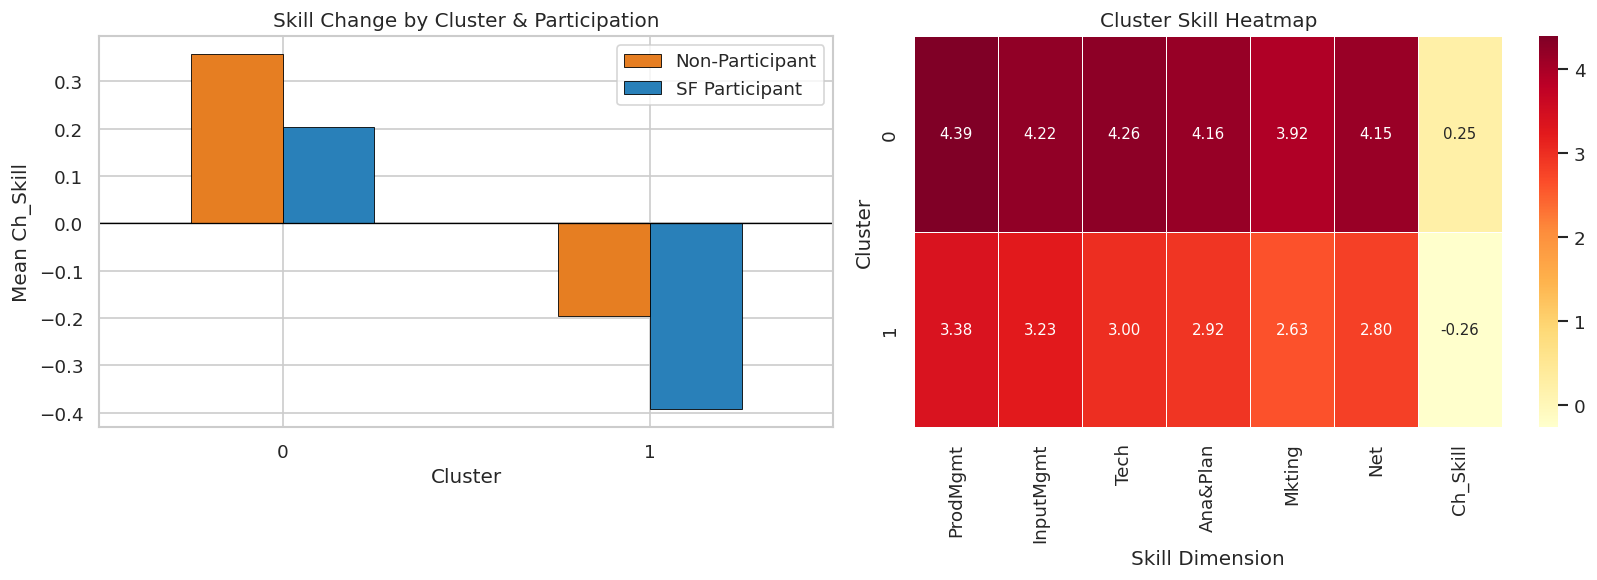

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ch_cl = df_main.groupby(['Cluster','sf_participant'])['Ch_Skill'].mean().unstack()
ch_cl.columns = ['Non-Participant','SF Participant']
ch_cl.plot(kind='bar', ax=axes[0], color=['#e67e22','#2980b9'], edgecolor='black', linewidth=0.5)
axes[0].set(title='Skill Change by Cluster & Participation',
             xlabel='Cluster', ylabel='Mean Ch_Skill')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=0)

heat_c = ['Avg_ProdManage','Avg_InputManage','Avg_Tech','Avg_Ana&Plan','Avg_Mkting','Avg_Network','Ch_Skill']
ht     = cluster_profile[heat_c].copy()
ht.columns = ['ProdMgmt','InputMgmt','Tech','Ana&Plan','Mkting','Net','Ch_Skill']
sns.heatmap(ht, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5, annot_kws={'size':9})
axes[1].set(title='Cluster Skill Heatmap', xlabel='Skill Dimension', ylabel='Cluster')

plt.tight_layout()
plt.savefig('fig_Framework.png', bbox_inches='tight')
plt.show()

In [65]:
skill_name_map = {
    'Avg_ProdManage' : 'Production Management',
    'Avg_InputManage': 'Input Management',
    'Avg_Tech'       : 'Technology',
    'Avg_Ana&Plan'   : 'Analysis & Planning',
    'Avg_Mkting'     : 'Marketing',
    'Avg_Network'    : 'Networking'
}

print('=' * 68)
print('     SMART FARMER LEARNING FRAMEWORK — per Cluster (+ SHAP Insight)')
print('=' * 68)

for i in range(best_k):
    row       = cluster_profile.loc[i]
    n_cnt     = df_main[df_main['Cluster']==i].shape[0]
    sf_rate   = row['sf_participant']
    avg_skill = row['All_Skill']
    ch_sk     = row['Ch_Skill']
    edu       = row['edu']
    agri_long = row['agri_long']
    weak_sk   = skill_name_map[pd.Series({k: row[k] for k in skill_name_map}).idxmin()]
    tier      = 'Advanced' if avg_skill >= 4.0 else ('Intermediate' if avg_skill >= 3.0 else 'Basic')

    # SHAP insight: top 3 ปัจจัยของกลุ่มนี้
    if i in shap_per_cluster.index:
        top_shap = shap_per_cluster.loc[i].sort_values(ascending=False).head(3)
        shap_str = ', '.join([f'{f} ({v:.3f})' for f, v in top_shap.items()])
    else:
        shap_str = 'N/A'

    print(f'\n--- Cluster {i} ({n_cnt} farmers | {sf_rate:.0%} SF | Tier: {tier}) ---')
    print(f'  Avg Skill={avg_skill:.2f}  Ch_Skill={ch_sk:.3f}  Edu={edu:.1f}  Exp={agri_long:.1f} yrs')
    print(f'  Weakest skill: {weak_sk}')
    print(f'  SHAP key drivers: {shap_str}')
    print(f'  Recommended Framework:')

    if tier == 'Basic':
        print('    Mode    : Group training + On-farm demonstration')
        print('    Content : Basic agronomy, input management, record-keeping')
        print(f'   Priority : ProdManage → InputManage → {weak_sk}')
        print('    Channel : Extension officer, Farmer Field School')
        print('    Duration: 3-day intensive + monthly follow-up')
    elif tier == 'Intermediate':
        print('    Mode    : Workshop + Peer learning network')
        print('    Content : Technology adoption, market linkage, agri-entrepreneurship')
        print(f'   Priority : {weak_sk} → Technology → Marketing')
        print('    Channel : Online modules + local farmer groups')
        print('    Duration: 5-day course + digital resource access')
    else:
        print('    Mode    : Mentoring + Innovation lab / study tour')
        print('    Content : Smart farming tech, value chain, networking')
        print(f'   Priority : {weak_sk} → Value Added → Network')
        print('    Channel : Community of practice + expert network')
        print('    Duration: Self-paced advanced modules + quarterly seminars')

print('\n' + '=' * 68)

     SMART FARMER LEARNING FRAMEWORK — per Cluster (+ SHAP Insight)

--- Cluster 0 (422 farmers | 72% SF | Tier: Advanced) ---
  Avg Skill=4.18  Ch_Skill=0.248  Edu=3.7  Exp=18.3 yrs
  Weakest skill: Marketing
  SHAP key drivers: Avg_InputManage (0.144), Avg_Ana&Plan (0.089), Avg_Mkting (0.068)
  Recommended Framework:
    Mode    : Mentoring + Innovation lab / study tour
    Content : Smart farming tech, value chain, networking
   Priority : Marketing → Value Added → Network
    Channel : Community of practice + expert network
    Duration: Self-paced advanced modules + quarterly seminars

--- Cluster 1 (411 farmers | 31% SF | Tier: Basic) ---
  Avg Skill=2.99  Ch_Skill=-0.256  Edu=3.2  Exp=23.3 yrs
  Weakest skill: Marketing
  SHAP key drivers: Avg_InputManage (0.155), Avg_Ana&Plan (0.122), sf_participant (0.086)
  Recommended Framework:
    Mode    : Group training + On-farm demonstration
    Content : Basic agronomy, input management, record-keeping
   Priority : ProdManage → Input

---
## 4. Summary

In [66]:
sig_t = [TRAIN_LABELS[j] for j, p_ in enumerate(p2[1:len(TRAIN_VARS)+1]) if p_ < 0.05]

print('=' * 60)
print('RESEARCH SUMMARY')
print('=' * 60)

print('\nObjective 1: Skill Change vs Training Characteristics')
print(f'  OLS R²: Model1={r2_1:.4f}  Model2(+demo)={r2_2:.4f}')
print(f'  Significant training predictors (p<0.05): {sig_t if sig_t else "none"}')

print('\n  SHAP Insight (SF Participants):')
top3_shap = mean_shap.sort_values(ascending=False).head(3)
for fname, fval in top3_shap.items():
    print(f'  - {fname}: mean|SHAP|={fval:.4f}')

print(f'\nObjective 2: ML Clustering Framework')
print(f'  Optimal k={best_k} | Silhouette={max(sil_scores):.4f}')
print(f'  RF Skill Prediction CV R²={cv_r2.mean():.4f}')

print('\nFigures generated:')
figs = ['fig_DiD.png','fig_Correlation.png','fig_Regression.png',
        'fig_SHAP_Beeswarm.png','fig_SHAP_Bar.png',
        'fig_Elbow.png','fig_RadarCluster.png','fig_PCA.png',
        'fig_FeatureImportance.png','fig_SHAP_Dependence.png',
        'fig_SHAP_Cluster.png','fig_Framework.png']
for f in figs:
    print(f'  {f}')

RESEARCH SUMMARY

Objective 1: Skill Change vs Training Characteristics
  OLS R²: Model1=0.0534  Model2(+demo)=0.0608
  Significant training predictors (p<0.05): ['Agri-Entrepreneurship']

  SHAP Insight (SF Participants):
  - Avg Mkting: mean|SHAP|=0.2274
  - Avg ProdManage: mean|SHAP|=0.0840
  - Avg Tech: mean|SHAP|=0.0757

Objective 2: ML Clustering Framework
  Optimal k=2 | Silhouette=0.1986
  RF Skill Prediction CV R²=0.1793

Figures generated:
  fig_DiD.png
  fig_Correlation.png
  fig_Regression.png
  fig_SHAP_Beeswarm.png
  fig_SHAP_Bar.png
  fig_Elbow.png
  fig_RadarCluster.png
  fig_PCA.png
  fig_FeatureImportance.png
  fig_SHAP_Dependence.png
  fig_SHAP_Cluster.png
  fig_Framework.png


Doing based line regression and adding some more metric 

In [67]:
# ============================================================
# Baseline Models (Revised Final Version)
# Feature Set C + Standardized Pipeline + Consistent Split
# ============================================================

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# ---------------------------------------------
# 1) Prepare data (Feature Set C)
# ---------------------------------------------
df_reg = df[feat_cols_rf + ['Ch_Skill']].dropna().copy()

X = df_reg[feat_cols_rf]
y = df_reg['Ch_Skill']

# ---------------------------------------------
# 2) Standardize features
# ---------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------------
# 3) Train–test split (consistent across models)
# ---------------------------------------------
X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ---------------------------------------------
# 4) Define models
# ---------------------------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest (ours)": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

# ---------------------------------------------
# 5) Train + Evaluate
# ---------------------------------------------
results = []

for name, model in models.items():
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae = mean_absolute_error(y_te, y_pred)

    results.append([name, round(r2, 3), round(rmse, 3), round(mae, 3)])

df_metrics = pd.DataFrame(results, columns=["Model", "R2", "RMSE", "MAE"])

print("\n=== Baseline Model Performance (Feature Set C) ===")
print(df_metrics.to_markdown(index=False))



=== Baseline Model Performance (Feature Set C) ===
| Model                |    R2 |   RMSE |   MAE |
|:---------------------|------:|-------:|------:|
| Linear Regression    | 0.27  |  0.562 | 0.446 |
| Ridge Regression     | 0.27  |  0.562 | 0.446 |
| Random Forest (ours) | 0.132 |  0.613 | 0.464 |
